# Ejercitación Unidad I: 
# Ecuaciones diferenciales de primer orden, aplicaciones y aproximación numérica.

### Ejercicio 01

El circuito eléctrico más sencillo está dado por 

<img src="1.png">

el circuito contiene un capacitor, un resistor y una fuente de voltaje. El comportamiento del resistor es definido por una constante positiva $R$ (la resistencia) medida en Ohms $[\Omega]$, el del capacitor por una constante positiva $C$ (la capacitancia) medida en Faraday $[F]$. El voltaje de entrada a través de la fuente de voltage en un tiempo dado $t$ se denota por $V(t)$ medida en Volts $[V]$. Esta fuente de voltaje puede ser una fuente constante como la de una batería, o puede ser variable.

Las variables que determinan el comportamiento del circuito en un tiempo particular $t$ son la corriente $i(t)$ y el voltaje a través del capacitor $v_c(t)$. La teoría de circuitos eléctricos establece que el voltaje $v_c$ satisface la ecuación diferencial
$$ RC \frac{d v_c}{dt} + v_c = V(t) $$

Suponga que un determinado circuito $R=2 [\Omega]$, $C=0.2 [F]$.

* a) Reescriba la EDO con los datos entregados en su forma $ v_c ' = f(t, v_c) $ identificando las variables independiente y dependiente.

* b) Suponga que el voltaje de entrada es nulo $V(t)=0 [V]$, construya un campo de direcciones asociado y describa el comportamiento de las soluciones conforme $t \to \infty$.

* c) Suponga esta vez que el voltaje de entrada es constante $V(t)=20 [V]$. Determine soluciones de equilibrio.

* d) Repita el análisis hecho en b) con $V(t)=20 [V]$.






In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import *
from scipy import integrate
sp.init_printing(use_latex='mathjax') # Importamos el módulo de latex para imprimir con notación matemática.



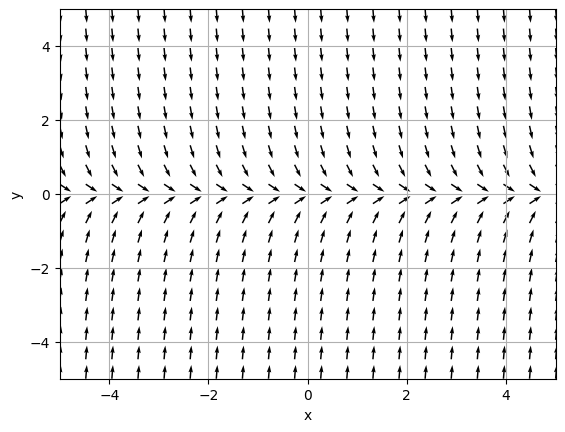

In [3]:
#Genera pares ordenados, de donde saldran los vectores.
X,Y=np.meshgrid(np.linspace(-5,5,20), np.linspace(-5,5,20))

#Se dan valores de los vectores
U = 1.0
V = -Y/0.4 #f(x,y)

#Normalizamos los vectores
N = np.sqrt(U ** 2 + V ** 2)
U = U / N
V = V / N

plt.quiver(X, Y, U, V) #graficamos los vectores con origen en (x,y) y término (u,v)
plt.xlim([-5, 5]) #limites en eje x
plt.ylim([-5, 5]) #limites en eje y

plt.xlabel('x') #etiqueta eje x
plt.ylabel('y') #etiqueta eje y
plt.grid()# para establecer red en la región

In [ ]:
# Resolviendo ecuación diferencial
# defino las incognitas
x = sp.Symbol('x', real=True )
y = sp.Function('y')

fv = 20 - y(x) / 0.4 
res = sp.dsolve(fv,y(x))
res

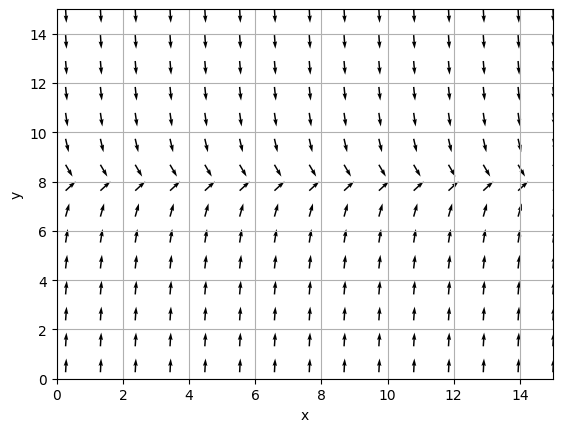

In [5]:
#Genera pares ordenados, de donde saldran los vectores.
X,Y=np.meshgrid(np.linspace(-5,15,20), np.linspace(-5,15,20))

#Se dan valores de los vectores
U = 1.0
V = 20 - Y/0.4 #f(x,y)

#Normalizamos los vectores
N = np.sqrt(U ** 2 + V ** 2)
U = U / N
V = V / N

plt.quiver(X, Y, U, V) #graficamos los vectores con origen en (x,y) y término (u,v)
plt.xlim([0, 15]) #limites en eje x
plt.ylim([0, 15]) #limites en eje y

plt.xlabel('x') #etiqueta eje x
plt.ylabel('y') #etiqueta eje y
plt.grid()# para establecer red en la región

### Ejercicio 02

La siguiente ecuación diferencial 
$$ y' = e^{-x^2-y^2} \ln|x| $$
es **separable** y su solución general puede ser encontrada al calcular:
$$ \int e^{y^2}  dy = \int e^{-x^2} \ln|x| dx. $$
Sin embargo, estas integrales no son calculables mediante métodos tradicionales. A pesar de lo anterior, hemos aprendido en este curso que es posible estudiar el comportamiento de las soluciones de manera numérica. Para ello considere el PVI:

$$  y'=  e^{-x^2-y^2} \ln|x| \quad ; \quad y(2) = 4$$

* a) Utilizando el método de Euler, determine una aproximación de $y(10)$ para:
    
    * a.1) Cantidad de iteraciones $n=300$
    * a.2) Paso $h=0,1$ 

* b)  Hemos aproximado $y(10)$ mediante la función error y la función hipergeométrica generalizada; suponga que el resultado que hemos obtenido en nuestra apoximación corresponde a:

$$ y(10) \approx 0,7213487756160880 $$

Determine el error entre esta aproximación y las aproximaciones que calculó mediante el método de Euler.

In [6]:
#Funcion
#x0 punto x inicial
#y0 punto y inicial
#xn punto final
#n cantidad de iteraciones

#n = xn - x0 / h



def Euler(f,x0,xn,y0,n): #nuestra función se llama Euler y sus datos de entrada son f,x0,xn,y0,n
    X = np.linspace(x0,xn,n+1)         
    Y = np.linspace(x0,xn,n+1)                 
    Y[0] = y0
    h = (xn-x0)/n #calculo de h, segun formula de sumas de riennman
    for i in range(n):
        Y[i+1] = Y[i] + h*f(X[i],Y[i])
    return Y

In [7]:
def f(x,y):
    return np.exp(-x**2-y**2)*np.log(np.abs(x))

Euler2 = Euler (f,2,10,4,300)[-1]
Euler2


np.float64(4.000000000387397)

In [8]:

Euler3 = Euler (f,2,10,4,80)[-1]
Euler3

np.float64(4.000000000443405)

### Ejercicio 03:

La EDO autónoma

$$m \frac{dy}{dt} = mg − ky^2$$

modela la velocidad $y(t)$ de un cuerpo de masa $m$ (en kg) que está cayendo bajo la influencia de la gravedad. Debido a que el término $–ky^2$ representa la resistencia del aire, la velocidad de un cuerpo que cae de una gran altura no aumenta sin límite conforme pasa el tiempo $t$.

Suponga que el cuerpo tiene masa 2 $[kg]$ y $k = g$ donde $g = 9, 8 \left[ \frac{m}{s^2} \right]$.

* (a) Construya un campo de direcciones para la EDO autónoma.
* (b) Determine y clasifique los puntos de equilibrio en atractor, repulsor o nodo.
* (c) Utilice la información anterior para encontrar la velocidad límite conforme $t \to \infty$.

C:\Users\nelof\AppData\Local\Temp\ipykernel_2876\2639081160.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


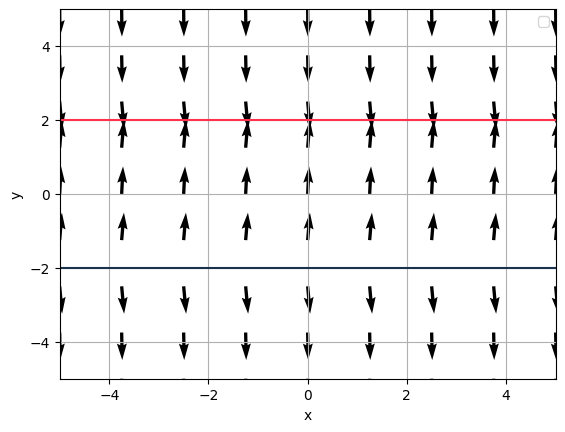

In [48]:
#Genera pares ordenados, de donde saldran los vectores.
X,Y=np.meshgrid(np.linspace(-5,5,9), np.linspace(-5,5,9))

#Se dan valores de los vectores
U = 1.0
V = (2*9.8) - (9.8 * Y**2) / 2 #f(x,y)

#Normalizamos los vectores
N = np.sqrt(U ** 2 + V ** 2)
U = U / N
V = V / N

plt.quiver(X, Y, U, V) #graficamos los vectores con origen en (x,y) y término (u,v)
plt.xlim([-5, 5]) #limites en eje x
plt.ylim([-5, 5]) #limites en eje y

plt.xlabel('x') #etiqueta eje x
plt.ylabel('y') #etiqueta eje y
plt.grid()# para establecer red en la región

x=np.linspace(-5,5, 200)
y1= 0*x + 2
y2= 0*x - 2

plt.plot(x,y1,color=(1,0.2,0.3))
plt.plot(x,y2,color=(0.1,0.2,0.3))
plt.legend()
plt.show()      

In [ ]:
#Para y = 2 el punto es un atractor
#Para y = -2 el punto es un repulsor 

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from sympy import *
from scipy import integrate
sp.init_printing(use_latex='mathjax') # Importamos el módulo de latex para imprimir con notación matemática.

# Resolviendo ecuación diferencial
# defino las incognitas
x = sp.Symbol('x', real=True )
y = sp.Function('y')

# expreso la ecuacion
f = (2*9.8) - (9.8 * y(x)**2) / 2 #f(x,y)
sp.Eq(y(x).diff(x), f)
sp.dsolve(y(x).diff(x) - f)

x + 0.0510204081632653⋅log(1.0⋅y(x) - 2.0) - 0.0510204081632653⋅log(1.0⋅y(x) + ↪

↪  2.0) = C₁

### Ejercicio 04:

Cuando se combinan ciertas clases de reacciones químicas, la razón con la que se forman los nuevos componentes se modela por la ecuación diferencial autónoma:

$$\frac{dx}{dt} = k[x^2 − (\alpha  + \beta)x + \alpha \beta],$$

donde $k > 0$ es una constante de proporcionalidad, $0 < \alpha < \beta$, y $x(t)$ denota el número de gramos del nuevo componente al tiempo $t$. Considere el caso en que $k = \frac{3}{2},$  $\alpha = 2$ y $\beta = 5$.

* (a) Construya un campo de direcciones para la EDO autónoma.
* (b) Determine y clasifique los puntos de equilibrio en atractor, repulsor o nodo.
* (c) Utilizando la información anterior, prediga el comportamiento de $x(t)$ para diferentes condiciones iniciales $x(0) = x_0$ conforme $t \to \infty$. Relacione este resultado con el contexto del problema.

### Ejercicio 05:

Considere la ecuación diferencial
$$ y'=2xy^2 $$

* (a) Resuelva la EDO a través de variables separabales.
* (b) Verifique que $y=0$ también es solución de la EDO y que no pertenece a la familia de soluciones encontrada en a) ¿Contradice esto el teorema de existencia y unicidad?
* (c) Construya un campo de direcciones asociado a la EDO.
* (d) Utilizando un ciclo `for`, grafique al menos 10 soluciones particulares sobre el campo de direcciones y compruebe que los resultados en (a) son correctos.


### Ejercicio 06:

La siguiente ecuación diferencial 
$$y' = e^{y^2}(1-y^2)$$
es **separable** y **autónoma** y su solución general puede ser encontrada integrando 
$$\int \frac{1}{e^{y^2}(1-y^2)}  dy = \int dx$$
pero la integral respecto a $y$ no se puede calcular mediante técnicas estándar. A pesar de lo anterior, es posible estudiar su comportamiento de manera cualitativa.

* (a) Encuentre las soluciones de equilibrio de la EDO.
* (b) Construya un campo de direcciones asociado a la EDO.
* (c) Grafique las soluciones de equilibro en el campo de direcciones (Para graficar funciones constantes se sugiere utilizar, por ejemplo, $y=c x^0$ donde corresponda).
* (d) Determine $\displaystyle\lim_{x \to \infty} y(x)$ si $y(x)$ es una solución particular para el PVI
$$y' = e^{y^2}(1-y^2) \quad ; \quad y(0)=y_0$$
para 
    * $y_0=0$
    * $y_0=1$
    * $y_0=-3$
    * $y_0=2$

### Ejercicio 07:

La siguiente ecuación diferencial 
$$ y' = e^{-x^2} $$
es separable y su solución general está dada por 
$$ y = \int e^{-x^2} dx $$
pero la función $f(x)= e^{-x^2}$ no tiene primitiva, por ende no es posible determinar una solución explícita. A pesar de lo anterior, es posible ver el comportamiento gráfico de la solución.

* a) Construya un campo de direcciones asociado a la EDO.

* b) Determine (si es posible) el comportamiento de $y$ cuando $x \to \infty$, para la condición inicial $y(3)=0$.

* c) Justifique si la solución que pasa por $(3,0)$ es una función acotada.

    * hint: Recuerde que: Una función $f:I \subset \mathbb{R} \to \mathbb{R}$ se dice acotada, si existe $M > 0$ tal que
$ |f(x)|< M , \quad \forall x \in I.  $

* d) A partir del campo de direcciones, justifique si existe alguna solución constante.

### Ejercicio 08:
Usando comando `dsolve` resuelva las siguientes EDOs:

* $y' =  \left( \dfrac{y}{x} \right)  + \ln \left( \dfrac{y}{x} \right)$
* $(y-\tan y \cos^2 x)dx + \left( \sin x \cos x - x \dfrac{\cos^2 x}{\cos^2 y} \right) dy = 0$
* $\sin x - x \cos x - 3x^2 (y-x)^2+3x^2(y-x)^2 y' = 0 \quad ; \quad y(1)=\sqrt{3}$

### Ejercicio 09:

Considere la ecuación diferencial:

$$dx + \dfrac{1}{y}\left( \sqrt{x^2+y^2}-x\right) dy =0$$

* (a) Muestre que $\mu(x,y) = \frac{1}{\sqrt{x^2+y^2}}$ es un factor integrante de la EDO.
* (b) Resuelv la ecuación diferencial.

### Ejercicio 10:

Considere la EDO

$$y'=\tan^2(y)-\csc^2(y)-3$$

* (a) Encuentre todas las soluciones estacionarias de la EDO autónoma
* (b) Construya un campo de direcciones para la EDO en la región $D=[-2\pi , 2\pi]\times[-2\pi , 2\pi]$ grafique las soluciones estacionarias sobre el campo y clasifique los puntos en atractor, repulsor o nodo.
* (c) Sin resolver la EDO, justifique el valor de $\displaystyle\lim_{x \to \infty} y(x)$ para una solución que pase por $y(\pi)=\pi$.